### Introduction to Manifold Diffusion Geometry

This notebook follows the computation in [Manifold Diffusion Geometry: Curvature, Tangent Spaces, and Dimension](https://arxiv.org/abs/2411.04100). The aim is to take a point cloud and compute familiar manifold geometry: tangent spaces, dimension, and scalar curvature.

We assume the data behave like points sampled from a low-dimensional manifold embedded in Euclidean space. We use diffusion geometry to estimate the intrinsic geometry from the heat flow on the data. The heat flow gives a Laplacian, and the Laplacian gives the carré du champ

$$
\Gamma(f,h)=g(\nabla f,\nabla h).
$$

Once $\Gamma$ is known, Riemannian geometry becomes linear algebra.

*The plots in this notebook are interactive*


In [8]:
from pathlib import Path
import site
import sys

import os

import numpy as np

from preprocess_file import compute_contrast_norm, sample_from_data_set
import numpy as np
from opt_einsum import contract
import plotly.io as pio

# # Keep imports on this repo/conda env when running the notebook directly.
# sys.path = [path for path in sys.path if not path.startswith(site.getusersitepackages())]
# if Path.cwd().name == "intro_notebooks":
#     sys.path.insert(0, "..")

# from diffusion_geometry import DiffusionGeometry
# from diffusion_geometry.visualisation import plot_scatter_3d, plot_2form_3d

# pio.renderers.default = "notebook_connected"


In [9]:


def get_angles_with_pca(patch):
    """Return the 2D dominant flow direction of a 3x3 flow patch.

    Port of getAnglesWithPCA.m. ``patch`` is an 18-element vector: the first 9
    entries are the horizontal (u) components, the next 9 the vertical (v)
    components. The result is the first principal component of the 9x2 matrix
    whose rows are ``(u_i, v_i)``.
    """
    X = np.column_stack([patch[:9], patch[9:18]])
    # MATLAB's pca centers the columns and uses the SVD; the first principal
    # direction is the leading right-singular vector of the centered data.
    Xc = X - X.mean(axis=0)
    _, _, vt = np.linalg.svd(Xc, full_matrices=False)
    return vt[0]


def compute_angles(patches):
    """Compute the flow angle (mod pi) of each patch.

    Port of computeAngles.m. Uses the first 18 columns of each row and returns
    a column vector of angles in ``[0, pi)``.
    """
    mrows, ncols = patches.shape
    if ncols < 18:
        raise ValueError("Data matrix has fewer than the expected 18 columns")

    xy = np.zeros((mrows, 2))
    for i in range(mrows):
        xy[i, :] = get_angles_with_pca(patches[i, :18])

    theta = np.arctan2(xy[:, 1], xy[:, 0])
    theta = np.mod(theta, np.pi)
    return theta.reshape(-1, 1)


def preprocess_folder_with_angles_all(folderpath, k=None, p=None, rng=None):
    """Preprocess every ``.flo`` file under ``folderpath``'s subfolders.

    Port of preprocessFolderWithAnglesAll.m.

    Parameters
    ----------
    folderpath : str
        Path to a folder whose subfolders contain ``.flo`` files.
    k, p :
        Unused; kept to match the MATLAB signature (the original k-NN density
        thresholding is commented out in the source).
    rng : numpy.random.Generator, optional
        Random generator used for patch sampling.

    Returns
    -------
    numpy.ndarray
        Matrix of preprocessed patches, one patch per row. Each row holds the
        18 flow values, the contrast norm, and the flow angle.
    """
    NUM_PATCHES = 385
    PATCH_SIZE = 3  # We always use 3x3 image patches.

    # MATLAB's dir() lists subfolders (including the folder itself via '.');
    # iterate the immediate subdirectories of folderpath.
    subfolders = sorted(
        entry.path for entry in os.scandir(folderpath) if entry.is_dir()
    )

    allpatches_list = []
    for tempdir in subfolders:
        # Get all .flo files in this subdirectory and process them.
        filelist = sorted(
            f for f in os.listdir(tempdir) if f.endswith(".flo")
        )
        numfiles = len(filelist)
        folderpatches = np.zeros((NUM_PATCHES * numfiles, 2 * PATCH_SIZE ** 2 + 1))
        for i, fname in enumerate(filelist):
            filepath = os.path.join(tempdir, fname)
            patches = sample_from_data_set(filepath, NUM_PATCHES, PATCH_SIZE, rng=rng)
            patches = compute_contrast_norm(patches)
            folderpatches[i * NUM_PATCHES:(i + 1) * NUM_PATCHES, :] = patches
        if numfiles > 0:
            allpatches_list.append(folderpatches)

    if not allpatches_list:
        return np.empty((0, 2 * PATCH_SIZE ** 2 + 2))

    allpatches = np.vstack(allpatches_list)

    # Compute angles over the entire collection and append as the last column.
    angles = compute_angles(allpatches)
    processedpatches = np.hstack([allpatches, angles])
    return processedpatches



In [10]:
path = "/home/martincc/Downloads/MPI-Sintel-complete/training/flow/"
result = preprocess_folder_with_angles_all(path)
print()
print("Processed patches shape:", result.shape)


Processed patches shape: (400785, 20)


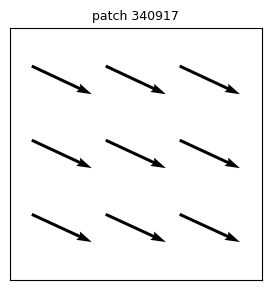

[340917]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_flow_patches(data, k=6, indices=None, colmajor=True, seed=0, show_mean=False):
    """
    data : (n, 18) or (n, 20) array of optical-flow patches.
           cols 0:9 = u1..u9, 9:18 = v1..v9, [18:20] = mean (ubar, vbar) if present.
    k    : number of patches to sample (ignored if `indices` given)
    """
    arr = data.detach().cpu().numpy() if hasattr(data, "detach") else np.asarray(data, float)
    n, d = arr.shape

    if indices is None:
        rng = np.random.default_rng(seed)
        indices = rng.choice(n, size=min(k, n), replace=False)
    indices = list(indices)
    k = len(indices)

    order = "F" if colmajor else "C"   # paper uses column-major
    def unpack(row):
        u = row[0:9].reshape(3, 3, order=order)
        v = row[9:18].reshape(3, 3, order=order)
        mean = row[18:20] if d >= 20 else np.zeros(2)
        return u, v, mean

    # shared scale so arrow lengths are comparable across patches
    mags = [np.hypot(*unpack(arr[i])[:2]).max() for i in indices]
    scale = max(np.max(mags), 1e-9) / 0.9   # longest arrow ~0.9 grid units

    # grid: column -> x, row -> y with row 0 on top so +v points up
    gx, gy = np.meshgrid([0, 1, 2], [2, 1, 0])

    cols = min(k, 3)
    rows = int(np.ceil(k / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows), squeeze=False)
    axes = axes.ravel()

    for ax, idx in zip(axes, indices):
        U, V, mean = unpack(arr[idx])
        ax.quiver(gx, gy, U, V, angles="xy", scale_units="xy",
                  scale=scale, pivot="mid", width=0.012, color="black")
        ax.set_xlim(-0.7, 2.7); ax.set_ylim(-0.7, 2.7)
        ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
        title = f"patch {idx}"
        if show_mean and d >= 20:
            title += f"\nmean=({mean[0]:.2f}, {mean[1]:.2f})"
        ax.set_title(title, fontsize=9)

    for ax in axes[k:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    return indices

# usage
plot_flow_patches(result, k=9)                       # random 6
# plot_flow_patches(my_tensor, indices=[0, 12, 57])     # specific patches